In [1]:
from Libraries_plot import *

In [2]:
def montecarlo_stuff(static_val,ppf_val=0.5):
    static_val = static_val.clip(min=0)
                    
            # # Save results of the test model with validation dataset 
            


    dist_load_forecasted = scipy.stats.norm(loc=static_val.mean(axis=-1),
                                        scale=static_val.std(axis=-1))


    # upper_load_forecasted = dist_load_forecasted.ppf(0.7) 
    upper_load_forecasted = dist_load_forecasted.ppf(ppf_val) 

    upper_load_forecasted[np.where(np.isnan(upper_load_forecasted))] = (
    static_val[np.where(np.isnan(upper_load_forecasted))][:, 0])
    return upper_load_forecasted
def load_scalers(city, ppf_static, ppf_helper,delay,phi):
    ''' Load the scalers for the static and shared data.'''
   
    static_scaler = pickle.load(open(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/Th_{delay}/block_1_minmaxscaler.pkl'), 'rb'))
    shared_scaler = pickle.load(open(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/block_2_minmaxscaler.pkl'), 'rb'))
    return static_scaler, shared_scaler


def denormalize_normalize_static_shared(static,shared, static_scaler,shared_scaler, mae_forecasting, real_data, test_index_start):
    ''' Denormalize the static data using the scaler. '''
    static_denorm = static_scaler.inverse_transform(static) # Static = block 1
    shared_denorm = shared_scaler.inverse_transform(np.expand_dims(shared, axis=-1)) # Shared = block 2
    mae_denorm = np.zeros(mae_forecasting.shape) # MAE = helper
    for i in range(B):
        mae_denorm[:,:,i] = static_scaler.inverse_transform(mae_forecasting[:,:,i])
    ''' Normalize the data to be in the same scale as the real data.'''
    shared_norm = shared_denorm / 10e9 # Shared = block 2
    static_norm = static_denorm / 10e9 # Static = block 1
    mae_norm = mae_denorm / 10e9 # MAE = helper
    output_norm = real_data[test_index_start:] / 10e9 # Real test data

    diff = min(mae_norm.shape[0], output_norm.shape[0], shared_norm.shape[0], static_norm.shape[0])

    mae_norm_diff = mae_norm.shape[0] - diff
    output_norm_diff = output_norm.shape[0] - diff
    shared_norm_diff = shared_norm.shape[0] - diff
    static_norm_diff = static_norm.shape[0] - diff

    if mae_norm_diff != 0:
        mae_norm = mae_norm[mae_norm_diff:]
    if output_norm_diff != 0:
        output_norm = output_norm[output_norm_diff:]
    if shared_norm_diff != 0:
        shared_norm = shared_norm[shared_norm_diff:]
    if static_norm_diff != 0:
        static_norm = static_norm[static_norm_diff:]

    return static_norm, shared_norm, mae_norm, output_norm


def upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper):
    cap_static = np.load(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/Th_{delay}/cap_fore_uncer_test_block1_delay_{delay}_phi_{phi}_gamma_2_deltax_005.npy'))
    cap_shared=np.load(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy'))
    #cap_shared = np.load(f'Results/{city}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy')

    dist_cd = scipy.stats.norm(loc=cap_static.mean(axis=-1),
                               scale=cap_static.std(axis=-1))
    dist_cs = scipy.stats.norm(loc=cap_shared.mean(axis=-1),
                               scale=cap_shared.std(axis=-1))
    
    ppf_2_static = .999
    ppf_2_helper = .999

    upper_cd_static = dist_cd.ppf(ppf_2_static) # Can be changed. If set to 0.5 = mean
    upper_cd_static[np.where(np.isnan(upper_cd_static))] = (
        cap_static[np.where(np.isnan(upper_cd_static))][:, 0])
    upper_cs_shared = dist_cs.ppf(ppf_2_helper) # Can be changed. If set to 0.5 = mean 
    upper_cs_shared[np.where(np.isnan(upper_cs_shared))] = (
        cap_shared[np.where(np.isnan(upper_cs_shared))][:, 0])

    return upper_cd_static, upper_cs_shared

def load_mae_forecasting(city,static_scaler):
    mae_forecasting = np.transpose(np.load(os.path.join(ROOT_DIR,f'./{results_path}/{city}/helper_forecasting_delay_1.npy')), (0,2,1))
    
    return mae_forecasting

def load_real_data(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'./citys/{city}.csv'))
    #bordeaux = pd.read_csv(f'/home/sergi_alcala/AZTEC_extension/citys/{city}.csv')

    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    bordeaux = bordeaux.to_numpy()
    return bordeaux

In [3]:
def fun_total_cost(output_norm,cplus,static_norm,shared_norm,city_df,alpha,num_services,phi):

    gamma = 2 # positive slope always fix
    
    cplus_denorm = cplus * 10e9 
    static_denorm = static_norm * 10e9
    shared_denorm = shared_norm * 10e9
    output_denorm = output_norm * 10e9

    # print(f'output_denorm.shape: {output_denorm.shape},\n cplus_denorm.shape: {cplus_denorm.shape},\n static_denorm.shape: {static_denorm.shape},\n shared_denorm.shape: {shared_denorm.shape}')

    test_length=min(len(output_norm),len(shared_norm))
    # 1734 is the minimum lenght among the test timeseries produced, i.e., block 1, block 2, helper.
    # It may change city by city
    #test_length = 1734

    delta_i = np.zeros((test_length, num_services)) 
    rho_i = np.zeros((test_length, num_services))

    indexes_under = np.where((static_denorm[:test_length] - output_denorm[:test_length]) > 0)
    indexes_above = np.where((static_denorm[:test_length] - output_denorm[:test_length]) < 0)

    # Where the real load is below the allocated static, delta_i is equal to the real load.
    # In this case rho_i is equal to 0.

    for idx, element in enumerate(indexes_under[0]):
        delta_i[element, indexes_under[1][idx]] = output_denorm[element, indexes_under[1][idx]]

    # Where the real load is higher than the allocated static, delta_i is equal to the static denormalized.
    # In this case rho_i is equal to the difference between real load and static allocated.
        
    for idx, element in enumerate(indexes_above[0]):
        delta_i[element, indexes_above[1][idx]] = static_denorm[element, indexes_above[1][idx]]
        rho_i[element, indexes_above[1][idx]] = (output_denorm[element, indexes_above[1][idx]]
                                                                - static_denorm[element, indexes_above[1][idx]])
        
    cost_normalization_factor = (output_denorm[:test_length].max(axis=0)
                                - output_denorm[:test_length]).sum() * gamma

    # Amount of capacity overprovisioned, i.e. higher than real output

    overprovisioning = (static_denorm[:test_length]
                        + cplus_denorm.T[:test_length] - output_denorm[:test_length]).clip(min=0)

    # Cost of the overprovisioning.
    # It includes the leftover shared capacity that have been provided by block 2 but not used by block 3.
    # The total cost is normalized by the total real load.
    # cost_overprovisioning = ((overprovisioning.sum()
    #                         + (shared_denorm[:test_length] - cplus_denorm.T[:test_length]).clip(min=0).sum())
    #                         * gamma / cost_normalization_factor)
    


    cplus_all=cplus_denorm.T[:test_length].sum(axis=1).reshape(-1,1) ## Sum of all the used shared capacity for all the services

    cost_overprovisioning = ((overprovisioning.sum()
                            + (shared_denorm[:test_length] -cplus_all).clip(min=0).sum())
                            * gamma / cost_normalization_factor)
    
    cost_overprovisioning_static = (overprovisioning.sum() * gamma / cost_normalization_factor)
    cost_overprovisioning_shared = ((shared_denorm[:test_length] -cplus_all).clip(min=0).sum()
                            * gamma / cost_normalization_factor)

    slas = np.zeros((test_length, num_services))

    # Where the shared allocated is below rho_i it means that the real load is higher than the total capacity, i.e., slas violation

    slas[np.where((cplus_denorm.T[:test_length] - rho_i) < 0)] += 1

    # The cost of slas is equal to the total number of slas per app multiplied by the max load value of each app multiplied by alpha.

    # The cost is then normalized as for the overprovisioning.
    max_concatenated= city_df.max(axis=0)

    cost_slas = (slas.sum(axis=0) * alpha * max_concatenated / cost_normalization_factor).sum()


    eta = 2 # cost of instantiation

    delta_static = static_denorm[:test_length] - np.roll(static_denorm[:test_length], 1,axis=0)
    delta_static[0] = static_denorm[0]
    delta_shared = cplus_denorm.T[:test_length] - np.roll(cplus_denorm.T[:test_length], 1,axis=0)
    delta_shared[0] = cplus_denorm.T[0]

    cost_instantiation_static = np.zeros((test_length, num_services))
    cost_instantiation_static[np.where(delta_static > 0)] = eta * delta_i[np.where(delta_static > 0)]

    cost_instantiation_shared = np.zeros((test_length, num_services))

    cost_instantiation_shared[np.where(delta_shared > 0)] = eta * np.minimum(rho_i, cplus_denorm.T[:test_length])[np.where(delta_shared > 0)]

    cost_instantiation = (cost_instantiation_static.sum()
                        + cost_instantiation_shared.sum()) / cost_normalization_factor

    reconfiguration = np.zeros((test_length, num_services))
    reconfiguration[np.where(delta_shared != 0)] = phi * rho_i[np.where(delta_shared != 0)]

    cost_reconfiguration = reconfiguration.sum() / cost_normalization_factor

    total_cost = cost_overprovisioning + cost_slas + cost_instantiation + cost_reconfiguration

    return total_cost, cost_overprovisioning , cost_slas , cost_instantiation , cost_reconfiguration,slas.sum(axis=0),cost_overprovisioning_static, cost_overprovisioning_shared

In [4]:
def select_cplus_np(cplus_df):
    cplus_df_sel=cplus_df.iloc[:,5:10]
    cplus_df_sel_np=cplus_df_sel.T.to_numpy()
    return cplus_df_sel_np

In [5]:
def fun_test_index_start(city,delay):
    bordeaux= load_real_data(city)
    test_index_start = round(len(bordeaux)*0.8) + delay
    return test_index_start

In [6]:
def cost_slas_analysis(city,ppf_helper,ppf_static,phi,alpha,delay,results_path,save_raw_data=False):
        # print(f'City: {city}, ppf_static: {ppf_static}, ppf_helper: {ppf_helper}, phi: {phi}, alpha: {alpha}')
        csv_path=f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv'
        # print(csv_path)
        
        if os.path.exists(csv_path):
                test_index_start=fun_test_index_start(city,delay)
              
                cplus_df=pd.read_csv(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')
                cplus_df_sel_np=select_cplus_np(cplus_df)
                
                static_scaler, shared_scaler = load_scalers(city, ppf_static, ppf_helper,delay,phi)
                real_data, mae_forecasting=load_real_data(city),load_mae_forecasting(city,static_scaler)
                static,shared=upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper)
                static_norm, shared_norm, mae_norm, output_norm = denormalize_normalize_static_shared(static, shared, static_scaler, shared_scaler, mae_forecasting, real_data, test_index_start)
                

                # length=min(static_norm.shape[0],shared_norm.shape[0],output_norm.shape[0])
                # print(f'static_norm.shape: {static_norm.shape}, shared_norm.shape: {shared_norm.shape}, output_norm.shape: {output_norm.shape},mae_norm_shape: {mae_norm.shape}')
                # print(length)
                total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas ,cost_overprovisioning_static, cost_overprovisioning_shared = fun_total_cost(output_norm,cplus_df_sel_np,static_norm,shared_norm,real_data,alpha,num_services,phi)
                
                if save_raw_data:
                        if not os.path.exists(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}'):
                                os.makedirs(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}')
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/static_norm.npy',static_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/shared_norm.npy',shared_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/mae_norm.npy',mae_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/output_norm.npy',output_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/slas.npy',slas)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_static.npy',cost_overprovisioning_static)
                        np.save(f'{results_path}/{city}/PHI_{phi}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_shared.npy',cost_overprovisioning_shared)
                #print(f'Total cost: {total_costs}, SLAS: {slas_sum} for city {city} with ppf_static {ppf_static} and ppf_helper {ppf_helper} amd phi {phi} and alpha {alpha}')
        else:
                total_cost=np.nan
                cost_slas=np.ones(num_services)*np.nan
                cost_overprovisioning=np.nan
                cost_instantiation=np.nan
                cost_reconfiguration=np.nan
                slas=[np.nan,np.nan,np.nan,np.nan,np.nan]
                
                
                #print('File not exist')
        return total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas


In [7]:
### Skip warnings
import warnings
warnings.filterwarnings("ignore")

In [8]:
# ROOT_DIR = ''
ROOT_DIR ='/home/sergi_alcala/sergi_data/AZTEC_extension/'
print(f'Root dir: {ROOT_DIR}')

Root dir: /home/sergi_alcala/sergi_data/AZTEC_extension/


In [9]:
def df_costs(total_costs_list,cost_overprovisioning_list,cost_slas_list,cost_instantiation_list,cost_reconfiguration_list,sla_perc_list_index_list):
    df_costs=pd.DataFrame({'total_costs':total_costs_list,'cost_overprovisioning':cost_overprovisioning_list,'cost_slas':cost_slas_list,'cost_instantiation':cost_instantiation_list,'cost_reconfiguration':cost_reconfiguration_list},index=sla_perc_list_index_list)
    return df_costs

In [10]:
cities = ['Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
        'Nice',  'Reims', 'Rennes', 'Paris','Strasbourg']
ALPHAS=[2,3,5]

PHIS = [1]


In [14]:

LOOKBACK = 6 # History given as input to the network. Could be modified if needed

gamma = 2 # Positive slope of the loss function
NUM_SERV_B1 = 5 # number of services for the block 1
NUM_SERV_H = 1 # number of services for the helper


lookback = 6
num_services = 5

B = 100


ppf_helper_list=[0.7]
ppf_static_list=[0.9]



SEL_SERVS=[0, 1, 2, 3, 4] #Services to be selected for Helper Block
# PHIS = [0.1,1,10] # Negative slope of the loss function TO BE MODIFIED 
# PHIS=[0.1]

cities = ['Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
        'Nice', 'Paris', 'Reims', 'Rennes', 'Strasbourg']
ALPHAS=[2,3,5]

PHIS = [0.1,1,10]
# TB_Fpath = 'Training_FIX_INSTANTATION'
# results_path = 'Results_Optimal_Cities_denorm'
results_path = 'Results_Optimal_Cities_denorm_loss_RAW'




total_costs_list=[]
cost_overprovisioning_list=[]
cost_slas_list=[]
cost_instantiation_list=[]
cost_reconfiguration_list=[]


save_raw_data=True

sla_perc_list_index_list=[]
slas_count_list=[]
delay_list=[]

results_path = ROOT_DIR+results_path
for city in cities:
    for ppf_helper in (ppf_helper_list):
        for ppf_static in (ppf_static_list):
            for phi in (PHIS):
                for alpha in (ALPHAS):
                    
                    
                    if results_path=='Results_old':
                        delay=6
                    elif results_path=='Results_AZTEC_6':

                        delay=5
                    
                    else:
                        delay=np.load (f'{results_path}/{city}/PHI_{phi}/ETA_2/overall_optimal_window.npy')
                    # if city == 'Grenoble' and phi == 0.1:
                    #     delay=84
                    # print(f' Delay {delay}')
                    delay_list.append(delay)
                    total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas=cost_slas_analysis(city,ppf_helper,ppf_static,phi,alpha,delay,results_path,save_raw_data)
                    total_costs_list.append(total_cost)
                    cost_slas_list.append(cost_slas)
                    cost_overprovisioning_list.append(cost_overprovisioning)
                    cost_instantiation_list.append(cost_instantiation)
                    cost_reconfiguration_list.append(cost_reconfiguration)
                    sla_perc_list_index=f'{city}_ppf_static_{ppf_static}_ppf_helper_{ppf_helper}_phi_{phi}_alpha_{alpha}_delay_{delay}'
                    sla_perc_list_index_list.append(sla_perc_list_index)
                    slas_count_list.append(slas)
                   

FileNotFoundError: [Errno 2] No such file or directory: '/home/sergi_alcala/sergi_data/AZTEC_extension/.//home/sergi_alcala/sergi_data/AZTEC_extension/Results_Optimal_Cities_denorm_loss_RAW/Dijon/helper_forecasting_delay_1.npy'

In [12]:
aaa= pd.DataFrame(delay_list,index=sla_perc_list_index_list,columns=['delay'])

In [13]:
aaa

,delay
Bordeaux_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_54,54
Bordeaux_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_54,54
Bordeaux_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_54,54
Bordeaux_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_18,18
Bordeaux_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_3_delay_18,18
...,...
Toulouse_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_3_delay_5,5
Toulouse_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_5_delay_5,5
Toulouse_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_5,5
Toulouse_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_3_delay_5,5


In [14]:
aaa = aaa[aaa.index.str.contains('alpha_2')]

In [15]:
b_city = aaa[aaa.index.str.contains(city)]

In [16]:
delay_phis = np.zeros((len(cities),len(PHIS)))
for j,city in enumerate(cities):
    for i,phi in enumerate(PHIS):
    
        b_city = aaa[aaa.index.str.contains(city)]
        delay_phis[j,i] = b_city[b_city.index.str.contains(f'phi_{phi}')].delay.values[0]

In [17]:
cities

['Bordeaux',
 'Dijon',
 'Grenoble',
 'Lille',
 'Lyon',
 'Marseille',
 'Montpellier',
 'Nantes',
 'Nice',
 'Reims',
 'Rennes',
 'Paris',
 'Strasbourg',
 'Toulouse']

In [18]:
delay_phis

array([[54., 18.,  5.],
       [23.,  4., 10.],
       [74.,  4.,  4.],
       [20.,  4.,  3.],
       [20., 16.,  4.],
       [18., 18.,  6.],
       [68., 20.,  4.],
       [20.,  4.,  4.],
       [68.,  4.,  4.],
       [13.,  4.,  6.],
       [ 4., 13.,  7.],
       [21., 18.,  7.],
       [63., 20.,  4.],
       [22.,  5.,  5.]])

In [61]:
ccc = pd.DataFrame(delay_phis,index=cities,columns=PHIS)

In [63]:
ccc.T

,Bordeaux,Dijon,Grenoble,Lille,Lyon,Marseille,Montpellier,Nantes,Nice,Reims,Rennes,Paris,Strasbourg,Toulouse
0.1,54.0,23.0,74.0,20.0,20.0,18.0,68.0,20.0,68.0,13.0,4.0,21.0,63.0,22.0
1.0,18.0,4.0,4.0,4.0,16.0,18.0,20.0,4.0,4.0,4.0,13.0,18.0,20.0,5.0
10.0,5.0,10.0,4.0,3.0,4.0,6.0,4.0,4.0,4.0,6.0,7.0,7.0,4.0,5.0


Text(0.5, 1.0, 'Optimal window for different cities')

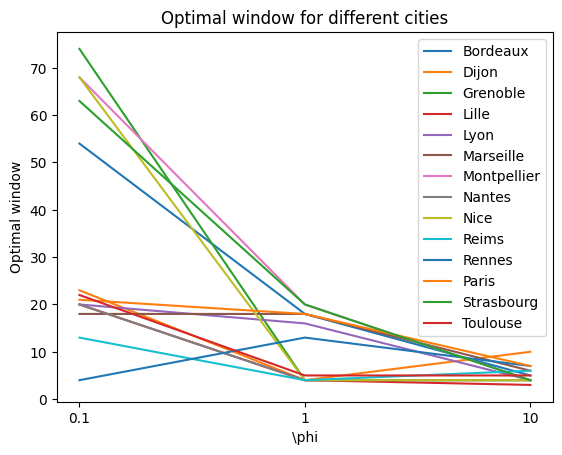

In [21]:
plt.plot(delay_phis.T)
plt.legend(cities)
plt.xticks(range(3),PHIS)
plt.xlabel(r'\phi')
plt.ylabel('Optimal window')
plt.title('Optimal window for different cities')

In [23]:
df_costs_=df_costs(total_costs_list,cost_overprovisioning_list,cost_slas_list,cost_instantiation_list,cost_reconfiguration_list,sla_perc_list_index_list)

In [24]:
df_costs_[df_costs_.index.str.contains('ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Bordeaux_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_54,0.546854,0.247775,0.260313,0.034676,0.004090
Dijon_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_23,0.398301,0.134920,0.227804,0.032437,0.003141
Grenoble_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_74,0.548472,0.194179,0.306522,0.042872,0.004898
Lille_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_20,0.479263,0.210274,0.22044,0.044750,0.003799
Lyon_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_20,0.362066,0.192816,0.133534,0.033071,0.002646
Marseille_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_18,0.402905,0.187052,0.182187,0.031293,0.002372
Montpellier_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_68,0.649668,0.288380,0.29541,0.058988,0.006890
Nantes_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_20,0.390841,0.185070,0.166795,0.035703,0.003273
Nice_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_68,0.610977,0.254320,0.2855,0.063980,0.007179
Reims_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_13,0.420128,0.118024,0.266316,0.033133,0.002656


In [25]:
df_costs_[df_costs_.index.str.contains('ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Bordeaux_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_18,0.307642,0.208536,0.082357,0.011723,0.005027
Dijon_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_4,0.266202,0.128683,0.10489,0.029753,0.002876
Grenoble_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_4,0.289152,0.131776,0.124875,0.029938,0.002562
Lille_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_4,0.315928,0.201036,0.060177,0.053363,0.001352
Lyon_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_16,0.283935,0.199040,0.064943,0.015776,0.004177
Marseille_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_18,0.350989,0.222603,0.104557,0.016912,0.006916
Montpellier_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_20,0.380037,0.217875,0.132933,0.018612,0.010617
Nantes_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_4,0.248182,0.154239,0.050482,0.042355,0.001106
Nice_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_4,0.306854,0.153351,0.107695,0.042149,0.003659
Reims_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_4,0.295094,0.137877,0.121838,0.032852,0.002527


In [26]:
df_costs_[df_costs_.index.str.contains('ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Bordeaux_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_5,0.330302,0.295463,0.008356,0.025744,0.000740
Dijon_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_10,0.315341,0.267805,0.030363,0.014129,0.003043
Grenoble_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_4,0.320981,0.268695,0.022151,0.028150,0.001985
Lille_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_3,0.427437,0.342992,0.017391,0.064139,0.002916
Lyon_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_4,0.352100,0.299478,0.005279,0.046379,0.000964
Marseille_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_6,0.379651,0.336984,0.010143,0.031067,0.001458
Montpellier_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_4,0.376094,0.317437,0.012186,0.045085,0.001386
Nantes_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_4,0.332133,0.282289,0.007236,0.041661,0.000946
Nice_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_4,0.350931,0.285845,0.022476,0.039952,0.002658
Reims_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_6,0.325029,0.275596,0.023681,0.024210,0.001541


In [27]:
Paris = df_costs_[df_costs_.index.str.contains('Paris_ppf_static_0.9_ppf_helper_0.7_')]

In [28]:
Paris

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_21,0.362719,0.243622,0.084623,0.032099,0.002376
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_21,0.410093,0.267032,0.107636,0.033042,0.002382
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_21,0.479820,0.297160,0.146948,0.033352,0.002361
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_18,0.378470,0.298603,0.056837,0.017225,0.005805
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_3_delay_18,0.414431,0.319986,0.070095,0.017735,0.006616
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_5_delay_18,0.466408,0.344543,0.096801,0.018294,0.006770
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_7,0.399759,0.352514,0.006963,0.039312,0.000970
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_3_delay_7,0.403179,0.352774,0.010012,0.039313,0.001079
Paris_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_5_delay_7,0.411339,0.355199,0.015745,0.039316,0.001079


In [29]:
Phi = [0.1,1,10]
Alpha = [2,3,5]

In [30]:
def df_eta(df,eta):
    df2 = df.copy()
    df2['cost_instantiation'] = df2['cost_instantiation']*eta
    df2['total_costs'] = df2['cost_overprovisioning'] + df2['cost_instantiation'] + df2['cost_slas']  + df2['cost_reconfiguration']
    return df2


def phi_etas(df1,df2,df3):
    df = pd.concat([df1['total_costs'],df2['total_costs'],df3['total_costs']],axis=1)
    df.columns = ['eta_2','eta_10','eta_20']
    return df
def phi_etas_merged_city(df_costs,city):
    df_costs = df_costs_[df_costs_.index.str.contains(f'{city}_ppf_static_0.9_ppf_helper_0.7_')]
    city_df = df_costs[df_costs.index.str.contains('alpha_2')]
    city_df_eta_10 = df_eta(city_df,5)
    city_df_eta_20 = df_eta(city_df,10)
    df_merged = phi_etas(city_df,city_df_eta_10,city_df_eta_20)
    return df_merged
   


In [31]:
df_costs_nan = df_costs_[df_costs_['total_costs'].isna()]

In [32]:
df_costs_nan[df_costs_nan.index.str.contains('ppf_static_0.9_ppf_helper_0.7_')]

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Rennes_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_4,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN
Rennes_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_4,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN
Rennes_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_4,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN
Strasbourg_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_63,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN
Strasbourg_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_63,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN
Strasbourg_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_63,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN
Toulouse_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_22,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN
Toulouse_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_3_delay_22,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN
Toulouse_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_5_delay_22,NaN,NaN,"[nan, nan, nan, nan, nan]",NaN,NaN


In [ ]:
"Dijon, reims, Rennes, Strasbourg, Grenoble,Montpellier,Nice"

In [33]:
cities

['Bordeaux',
 'Dijon',
 'Grenoble',
 'Lille',
 'Lyon',
 'Marseille',
 'Montpellier',
 'Nantes',
 'Nice',
 'Reims',
 'Rennes',
 'Paris',
 'Strasbourg',
 'Toulouse']

In [51]:
cities_notna = ['Bordeaux',
 'Dijon',
 'Grenoble',
 'Lille',
 'Lyon',
 'Marseille',
 'Montpellier',
 'Nantes',
 'Nice',
 'Paris'
]


#  cities_notna = ['Bordeaux',
#  'Grenoble',
#  'Lille',
#  'Lyon',
#  'Marseille',
#  'Montpellier',
#  'Nantes',
#  'Nice',
#  'Paris'
#  ]

#  "Dijon, reims, Rennes, Strasbourg, Grenoble,Montpellier,Nice"

In [52]:
df_merged = phi_etas_merged_city(df_costs_,'Reims')

In [53]:
df_merged

,eta_2,eta_10,eta_20
Reims_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_13,0.420128,0.552662,0.718329
Reims_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_4,0.295094,0.426503,0.590764
Reims_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_6,0.325029,0.42187,0.542921


In [54]:
df_merged

,eta_2,eta_10,eta_20
Reims_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_13,0.420128,0.552662,0.718329
Reims_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_4,0.295094,0.426503,0.590764
Reims_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_6,0.325029,0.42187,0.542921


In [55]:
df_merged = phi_etas_merged_city(df_costs_,cities[3])

In [56]:
df_merged

,eta_2,eta_10,eta_20
Lille_ppf_static_0.9_ppf_helper_0.7_phi_0.1_alpha_2_delay_20,0.479263,0.658261,0.882009
Lille_ppf_static_0.9_ppf_helper_0.7_phi_1_alpha_2_delay_4,0.315928,0.52938,0.796194
Lille_ppf_static_0.9_ppf_helper_0.7_phi_10_alpha_2_delay_3,0.427437,0.683992,1.004686


In [57]:
cities_notna

['Bordeaux',
 'Dijon',
 'Grenoble',
 'Lille',
 'Lyon',
 'Marseille',
 'Montpellier',
 'Nantes',
 'Nice',
 'Paris']

In [58]:
# cities_notna =cities
rows = 2
cols = 5

phi_etas_cities_matrix =np.zeros((len(cities_notna),3,3))

for i in range(len(cities_notna)):
    df_merged = phi_etas_merged_city(df_costs_,cities_notna[i])
    # print (df_merged)
    df_merged =df_merged.to_numpy().reshape(3,3)
    phi_etas_cities_matrix[i,:,:] =  df_merged[:,:]

phi_etas_cities_matrix_plot_shape = phi_etas_cities_matrix.reshape(rows,cols,3,3)  ####2,7 because we want to plot the results in two rows and 7 columns ####3,3 because we have 3 phis and 3 etas
cities_notna_np =np.array (cities_notna)
cities_notna_np = cities_notna_np.reshape(rows,cols)


In [59]:
phi_etas_cities_matrix.shape

(10, 3, 3)

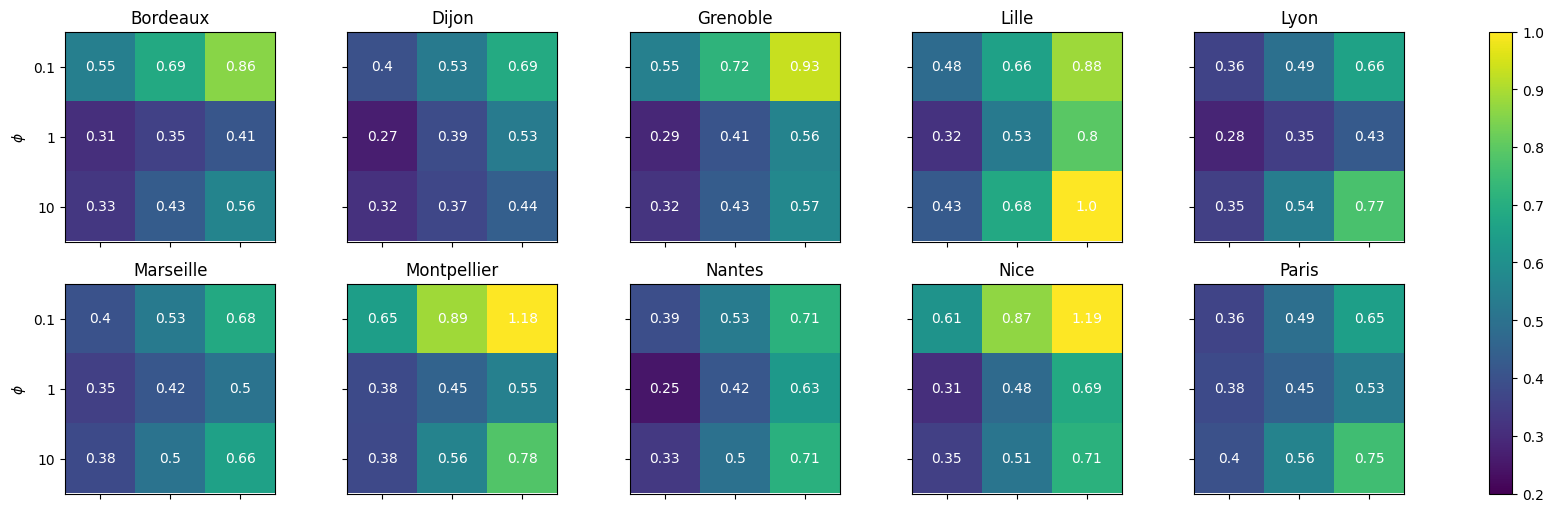

In [60]:

vmin = 0.2
vmax = 1
etas = [2,10,20]
Phi = [0.1,1,10]

fig, ax = plt.subplots(phi_etas_cities_matrix_plot_shape.shape[0],phi_etas_cities_matrix_plot_shape.shape[1],figsize=(22,6))

for k in range(phi_etas_cities_matrix_plot_shape.shape[0]):
    for l in range(phi_etas_cities_matrix_plot_shape.shape[1]):

        
        im = ax[k,l].imshow(phi_etas_cities_matrix_plot_shape[k,l],cmap='viridis',vmin=vmin,vmax=vmax)
        
        ax[k,l].set_yticks(np.arange(len(Phi)),labels='')
        ax[k,l].set_xticks(np.arange(len(etas)),labels='')
        ax[k,l].set_title(cities_notna_np[k,l])

        if l==0:
            ax[k,l].set_ylabel(r'$\phi$')
            ax[k,l].set_yticks(np.arange(len(Phi)),labels=Phi)
        if k==2:
            ax[k,l].set_xlabel(r'$\eta$')
            ax[k,l].set_xticks(np.arange(len(etas)),labels=etas)

        for i in range(len(Phi)):
                for j in range(len(etas)):
                    text = ax[k,l].text(j, i, phi_etas_cities_matrix_plot_shape[k,l][i, j].round(2),
                                ha="center", va="center", color="w")
                    

                    
fig.colorbar(im, ax=ax.ravel().tolist())
# fig.savefig('FIGS/phi_etas_cities_matrix.png',bbox_inches='tight')
# fig.savefig('FIGS/phi_etas_cities_matrix.pdf',bbox_inches='tight')


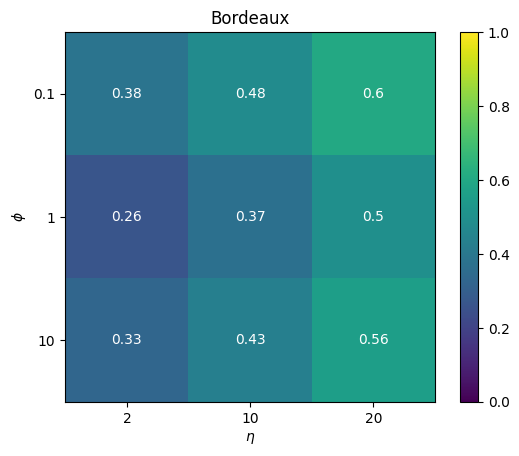

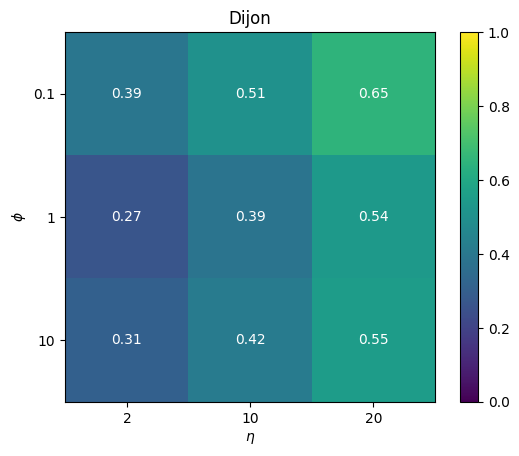

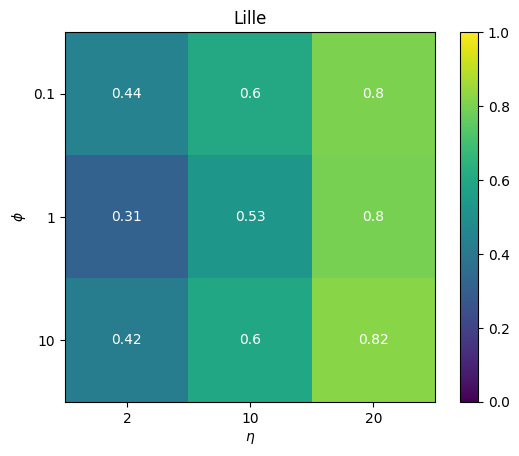

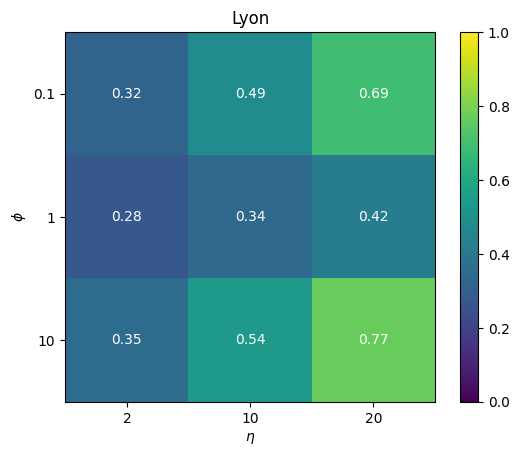

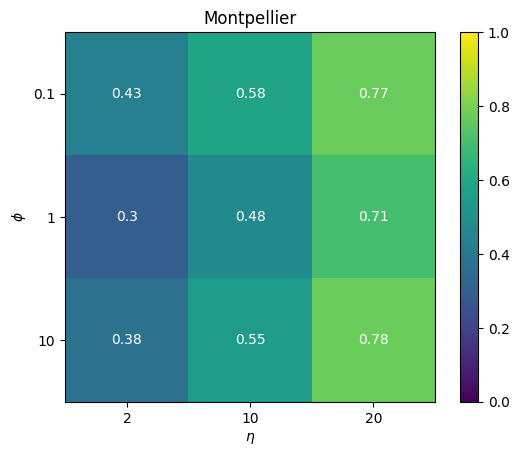

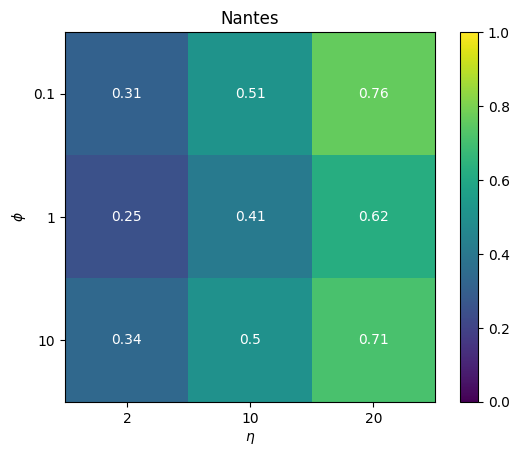

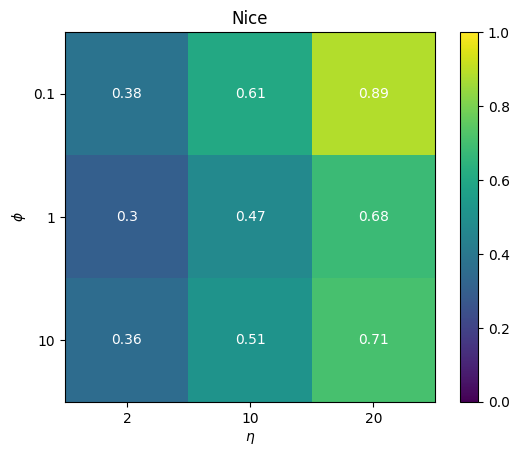

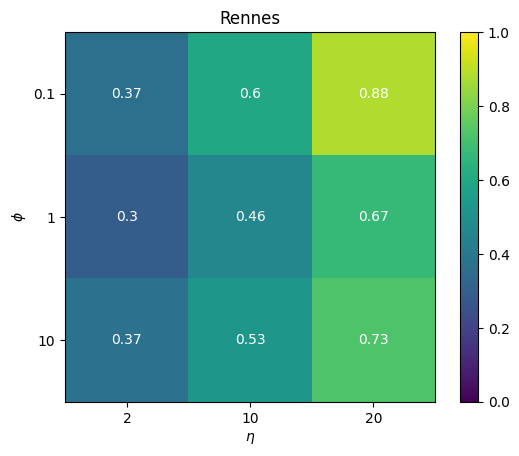

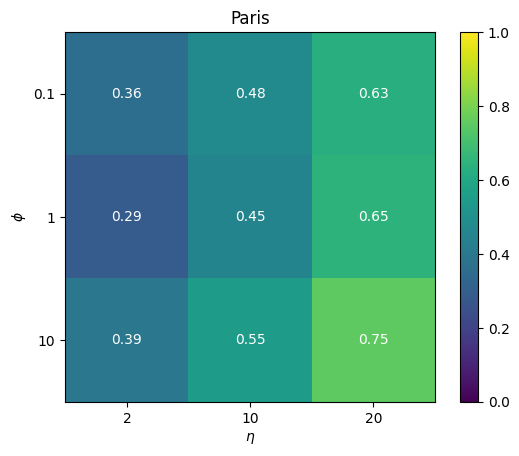

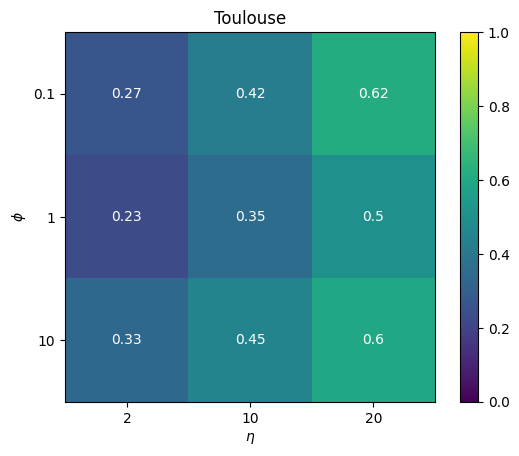

In [97]:
etas = [2,10,20]
for k in range(len(cities_notna)):
    
    fig, ax = plt.subplots()

    vmin = 0
    vmax = 1

    im = ax.imshow(phi_etas_cities_matrix[k],cmap='viridis',vmin=vmin,vmax=vmax)

    ax.set_xticks(np.arange(len(etas)),labels=etas)
    ax.set_yticks(np.arange(len(Phi)),labels=Phi)
    ax.set_xlabel(r'$\eta$')
    ax.set_ylabel(r'$\phi$')

    for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax.text(j, i, phi_etas_cities_matrix[k][i, j].round(2),
                        ha="center", va="center", color="w")


    cbar = ax.figure.colorbar(im, ax=ax)
    ax.set_title(cities_notna[k])

In [43]:
cities_notna

['Bordeaux',
 'Dijon',
 'Lille',
 'Lyon',
 'Montpellier',
 'Nantes',
 'Nice',
 'Rennes',
 'Paris',
 'Toulouse']

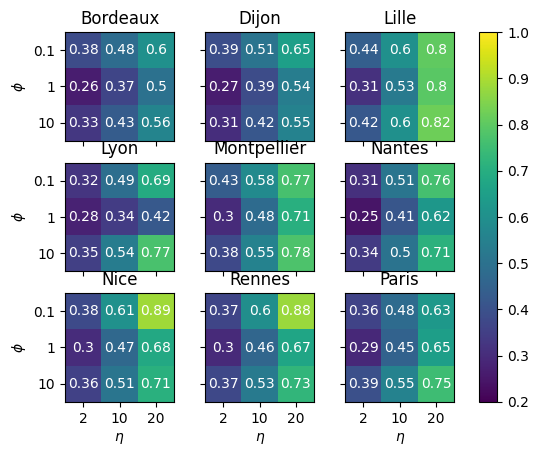

In [98]:
vmin = 0.2
vmax = 1

fig, ax = plt.subplots(3,3)
im = ax[0,0].imshow(phi_etas_cities_matrix[0],cmap='viridis',vmin=vmin,vmax=vmax)
ax[0,0].set_xticklabels('')
ax[0,0].set_yticks(np.arange(len(Phi)),labels=Phi)
ax[0,0].set_ylabel(r'$\phi$')
ax[0,0].set_title(cities_notna[0])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[0,0].text(j, i, phi_etas_cities_matrix[0][i, j].round(2),
                        ha="center", va="center", color="w")


ax[0,1].imshow(phi_etas_cities_matrix[1],cmap='viridis',vmin=vmin,vmax=vmax)
ax[0,1].set_xticklabels('')
ax[0,1].set_yticklabels('')
ax[0,1].set_title(cities_notna[1])

for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[0,1].text(j, i, phi_etas_cities_matrix[1][i, j].round(2),
                        ha="center", va="center", color="w")

ax[0,2].imshow(phi_etas_cities_matrix[2],cmap='viridis',vmin=vmin,vmax=vmax)
ax[0,2].set_xticklabels('')
ax[0,2].set_yticklabels('')
ax[0,2].set_title(cities_notna[2])

for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[0,2].text(j, i, phi_etas_cities_matrix[2][i, j].round(2),
                        ha="center", va="center", color="w")

ax[1,0].imshow(phi_etas_cities_matrix[3],cmap='viridis',vmin=vmin,vmax=vmax)
ax[1,0].set_ylabel(r'$\phi$')
ax[1,0].set_xticklabels('')
ax[1,0].set_yticks(np.arange(len(Phi)),labels=Phi)
ax[1,0].set_title(cities_notna[3])

for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[1,0].text(j, i, phi_etas_cities_matrix[3][i, j].round(2),
                        ha="center", va="center", color="w")

ax[1,1].imshow(phi_etas_cities_matrix[4],cmap='viridis',vmin=vmin,vmax=vmax)
ax[1,1].set_xticklabels('')
ax[1,1].set_yticklabels('')
ax[1,1].set_title(cities_notna[4])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[1,1].text(j, i, phi_etas_cities_matrix[4][i, j].round(2),
                        ha="center", va="center", color="w")

ax[1,2].imshow(phi_etas_cities_matrix[5],cmap='viridis',vmin=vmin,vmax=vmax)
ax[1,2].set_xticklabels('')
ax[1,2].set_yticklabels('')
ax[1,2].set_title(cities_notna[5])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[1,2].text(j, i, phi_etas_cities_matrix[5][i, j].round(2),
                        ha="center", va="center", color="w")

ax[2,0].imshow(phi_etas_cities_matrix[6],cmap='viridis',vmin=vmin,vmax=vmax)
ax[2,0].set_ylabel(r'$\phi$')
ax[2,0].set_xlabel(r'$\eta$')
ax[2,0].set_xticks(np.arange(len(etas)),labels=etas)
ax[2,0].set_yticks(np.arange(len(Phi)),labels=Phi)
ax[2,0].set_title(cities_notna[6])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[2,0].text(j, i, phi_etas_cities_matrix[6][i, j].round(2),
                        ha="center", va="center", color="w")

ax[2,1].imshow(phi_etas_cities_matrix[7],cmap='viridis',vmin=vmin,vmax=vmax)
ax[2,1].set_xticklabels('')
ax[2,1].set_yticklabels('')
ax[2,1].set_title(cities_notna[7])
ax[2,1].set_xlabel(r'$\eta$')
ax[2,1].set_xticks(np.arange(len(etas)),labels=etas)
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[2,1].text(j, i, phi_etas_cities_matrix[7][i, j].round(2),
                        ha="center", va="center", color="w")



ax[2,2].imshow(phi_etas_cities_matrix[8],cmap='viridis',vmin=vmin,vmax=vmax)
ax[2,2].set_xticklabels('')
ax[2,2].set_yticklabels('')
ax[2,2].set_title(cities_notna[8])
ax[2,2].set_xticks(np.arange(len(etas)),labels=etas)
ax[2,2].set_xlabel(r'$\eta$')
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[2,2].text(j, i, phi_etas_cities_matrix[8][i, j].round(2),
                        ha="center", va="center", color="w")
fig.colorbar(im, ax=ax.ravel().tolist())

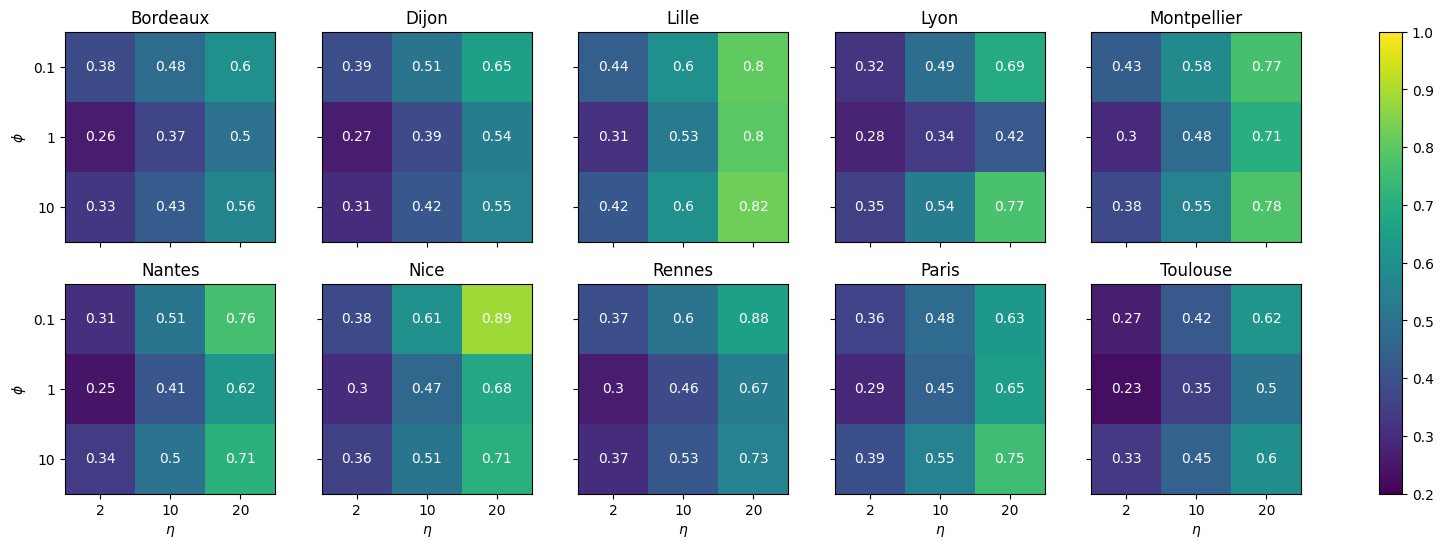

In [112]:
fig, ax = plt.subplots(2,5,figsize=(20,6))
im = ax[0,0].imshow(phi_etas_cities_matrix[0],cmap='viridis',vmin=vmin,vmax=vmax)
ax[0,0].set_xticklabels('')
ax[0,0].set_yticks(np.arange(len(Phi)),labels=Phi)
ax[0,0].set_ylabel(r'$\phi$')
ax[0,0].set_title(cities_notna[0])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[0,0].text(j, i, phi_etas_cities_matrix[0][i, j].round(2),
                        ha="center", va="center", color="w")
            
ax[0,1].imshow(phi_etas_cities_matrix[1],cmap='viridis',vmin=vmin,vmax=vmax)

ax[0,1].set_title(cities_notna[1])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[0,1].text(j, i, phi_etas_cities_matrix[1][i, j].round(2),
                        ha="center", va="center", color="w")

ax[0,2].imshow(phi_etas_cities_matrix[2],cmap='viridis',vmin=vmin,vmax=vmax)

ax[0,2].set_title(cities_notna[2])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[0,2].text(j, i, phi_etas_cities_matrix[2][i, j].round(2),
                        ha="center", va="center", color="w")
            
ax[0,3].imshow(phi_etas_cities_matrix[3],cmap='viridis',vmin=vmin,vmax=vmax)

ax[0,3].set_title(cities_notna[3])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[0,3].text(j, i, phi_etas_cities_matrix[3][i, j].round(2),
                        ha="center", va="center", color="w")


ax[0,4].imshow(phi_etas_cities_matrix[4],cmap='viridis',vmin=vmin,vmax=vmax)

ax[0,4].set_title(cities_notna[4])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[0,4].text(j, i, phi_etas_cities_matrix[4][i, j].round(2),
                        ha="center", va="center", color="w")
            
ax[1,0].imshow(phi_etas_cities_matrix[5],cmap='viridis',vmin=vmin,vmax=vmax)

ax[1,0].set_title(cities_notna[5])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[1,0].text(j, i, phi_etas_cities_matrix[5][i, j].round(2),
                        ha="center", va="center", color="w")
            
ax[1,1].imshow(phi_etas_cities_matrix[6],cmap='viridis',vmin=vmin,vmax=vmax)

ax[1,1].set_title(cities_notna[6])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[1,1].text(j, i, phi_etas_cities_matrix[6][i, j].round(2),
                        ha="center", va="center", color="w")

ax[1,2].imshow(phi_etas_cities_matrix[1],cmap='viridis',vmin=vmin,vmax=vmax)

ax[1,2].set_title(cities_notna[7])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[1,2].text(j, i, phi_etas_cities_matrix[7][i, j].round(2),
                        ha="center", va="center", color="w")

ax[1,3].imshow(phi_etas_cities_matrix[8],cmap='viridis',vmin=vmin,vmax=vmax)

ax[1,3].set_title(cities_notna[8])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[1,3].text(j, i, phi_etas_cities_matrix[8][i, j].round(2),
                        ha="center", va="center", color="w")
ax[1,4].imshow(phi_etas_cities_matrix[9],cmap='viridis',vmin=vmin,vmax=vmax)

ax[1,4].set_title(cities_notna[9])
for i in range(len(Phi)):
        for j in range(len(etas)):
            text = ax[1,4].text(j, i, phi_etas_cities_matrix[9][i, j].round(2),
                        ha="center", va="center", color="w")


ax[1,0].set_xticks(np.arange(len(etas)),labels=etas)
ax[1,0].set_xlabel(r'$\eta$')
ax[1,1].set_xticks(np.arange(len(etas)),labels=etas)
ax[1,1].set_xlabel(r'$\eta$')
ax[1,2].set_xticks(np.arange(len(etas)),labels=etas)
ax[1,2].set_xlabel(r'$\eta$')
ax[1,3].set_xticks(np.arange(len(etas)),labels=etas)
ax[1,3].set_xlabel(r'$\eta$')
ax[1,4].set_xticks(np.arange(len(etas)),labels=etas)
ax[1,4].set_xlabel(r'$\eta$')

ax[0,0].set_yticks(np.arange(len(Phi)),labels=Phi)
ax[0,0].set_ylabel(r'$\phi$')
ax[1,0].set_yticks(np.arange(len(Phi)),labels=Phi)
ax[1,0].set_ylabel(r'$\phi$')

ax[0,1].set_yticks(np.arange(len(Phi)),labels='')
ax[0,2].set_yticks(np.arange(len(Phi)),labels='')
ax[0,3].set_yticks(np.arange(len(Phi)),labels='')
ax[0,4].set_yticks(np.arange(len(Phi)),labels='')
ax[1,1].set_yticks(np.arange(len(Phi)),labels='')
ax[1,2].set_yticks(np.arange(len(Phi)),labels='')
ax[1,3].set_yticks(np.arange(len(Phi)),labels='')
ax[1,4].set_yticks(np.arange(len(Phi)),labels='')

ax[0,1].set_xticks(np.arange(len(etas)),labels='')
ax[0,2].set_xticks(np.arange(len(etas)),labels='')
ax[0,3].set_xticks(np.arange(len(etas)),labels='')
ax[0,4].set_xticks(np.arange(len(etas)),labels='')

                       

fig.colorbar(im, ax=ax.ravel().tolist())